In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder

# Load and clean data
df = pd.read_csv('data/telco-churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

print("Dataset shape:", df.shape)
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Dataset shape: (7032, 21)

Churn distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [2]:
# Feature engineering — convert categorical columns to numbers
df_model = df.copy()

# Convert binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Convert multi-category columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df_model = pd.get_dummies(df_model, columns=multi_cols)

# Drop customer ID (not useful for prediction)
df_model = df_model.drop('customerID', axis=1)

print("Features ready:", df_model.shape)
print("\nFirst 3 columns:", df_model.columns[:3].tolist())

Features ready: (7032, 41)

First 3 columns: ['gender', 'SeniorCitizen', 'Partner']


In [3]:
# Split data into features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Train Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

# Train Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print(f"\nLogistic Regression AUC: {lr_auc:.3f}")
print(f"Random Forest AUC:       {rf_auc:.3f}")

Training set: (5625, 40)
Test set: (1407, 40)


C:\Users\qianqian\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression AUC: 0.832
Random Forest AUC:       0.819


In [4]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain Logistic Regression with scaled data
lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1])

# Random Forest doesn't need scaling
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(f"Random Forest AUC:       {rf_auc:.3f}")

Logistic Regression AUC: 0.832
Random Forest AUC:       0.819


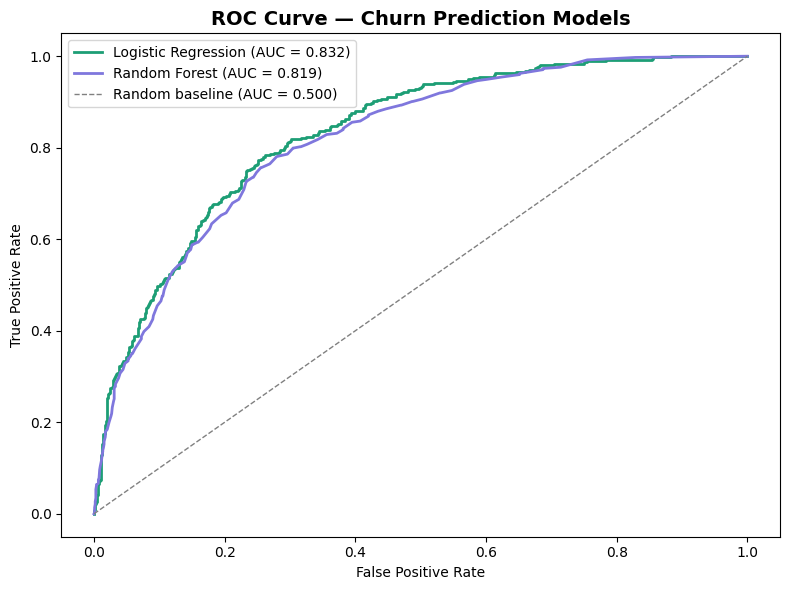

In [5]:
# Plot ROC curves for both models
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_scaled)[:,1])
ax.plot(lr_fpr, lr_tpr, color='#1D9E75', linewidth=2,
        label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
ax.plot(rf_fpr, rf_tpr, color='#7F77DD', linewidth=2,
        label=f'Random Forest (AUC = {rf_auc:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', 
        linewidth=1, label='Random baseline (AUC = 0.500)')

ax.set_title('ROC Curve — Churn Prediction Models', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

plt.tight_layout()
plt.savefig('charts/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

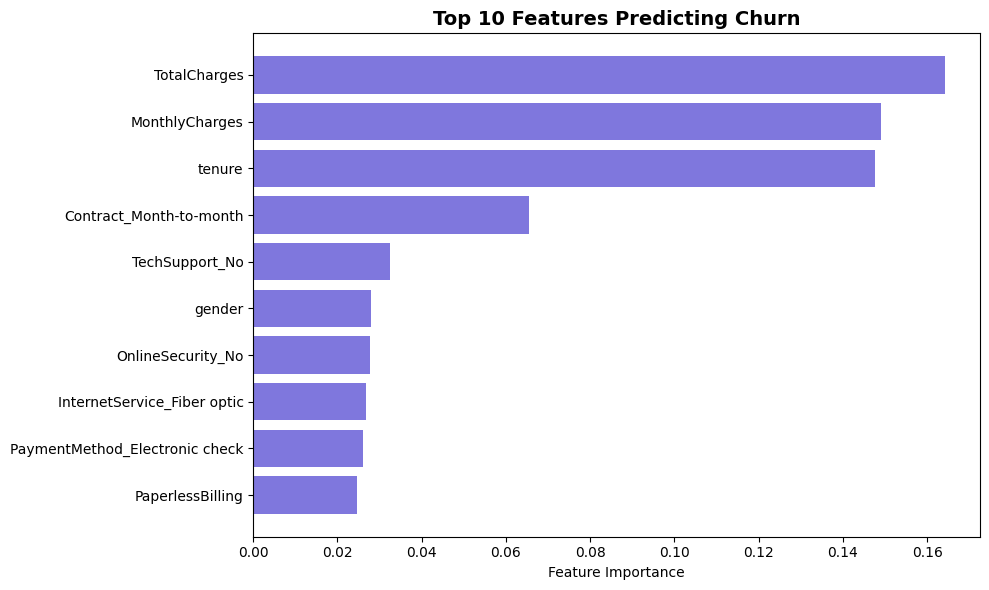

In [6]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(feature_importance['feature'][::-1],
               feature_importance['importance'][::-1],
               color='#7F77DD')

ax.set_title('Top 10 Features Predicting Churn', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings & Business Recommendations

### Model Performance
- Best model: Logistic Regression (AUC = 0.832)
- The model correctly identifies churners 83% of the time
- Significantly better than random guessing (AUC = 0.500)

### Finding 1: Financial signals are the strongest predictors
- TotalCharges, MonthlyCharges, and tenure are the top 3 features
- **Recommendation:** Flag users with high monthly charges but low 
  tenure as high-risk — intervene before month 6

### Finding 2: Contract type is a strong behavioural signal
- Month-to-month contract is the 4th strongest predictor
- **Recommendation:** Use the model to identify month-to-month users 
  most likely to churn and target them with upgrade offers

### Finding 3: Lack of support services predicts churn
- TechSupport_No and OnlineSecurity_No both appear in top 10
- **Recommendation:** Proactively offer support services to users 
  who haven't adopted them in their first 3 months

### Business Impact
If this model is deployed to flag the top 20% highest-risk users 
for proactive outreach, it could potentially reduce churn by 
identifying ~374 at-risk customers per month before they leave.